# Probe health with day-level embeddings
Following tutorial here: https://oxwearables.github.io/Sensori/tutorials/day-level-health/#prepare-the-analysis-data
The pre-processing notebook: tutorials/nhanes_preprocessing.ipynb(this outputs the .npy files same as my script is curently generating)
There is also the full tutorial notebook: tutorials/nhanes_evaluation.ipynb - I will be re-working this to operate on a small subset of my data


In [1]:
import json
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from umap import UMAP
import os

from scripts.tutorial_nhanes.prepare_nhanes_tabular import prepare_tabular
from sensori.inference import extract_embeddings # looks dodgy but does work

In [3]:
torch.cuda.is_available()

True

- first extract the embeddings - this code fetches the weights from huggingface

In [7]:
# Change this to the directory containing your preprocessed NHANES arrays.
PROCESSED_DATA_DIR = Path('/home/lucy/PycharmProjects/Sensori/data/sensori-data')
EMBEDDING_PATH = Path('mobilised_embeddings.npy')

# BATCH_SIZE = 100 needs about 70 GB of GPU memory for full-day inputs; reduce it if you run out.
BATCH_SIZE = 10
NUM_WORKERS = 6
SEED = 111

extract_embeddings(
    PROCESSED_DATA_DIR,
    output_path=EMBEDDING_PATH,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Total days loaded: 5192
Total unique participants: 1033
Loading data from: /home/lucy/PycharmProjects/Sensori/data/sensori-data
Saving embeddings to: /home/lucy/PycharmProjects/Sensori/experiments/mobilised_embeddings.npy


Validation: |          | 0/? [00:00<?, ?it/s]

Saved embeddings to: /home/lucy/PycharmProjects/Sensori/experiments/mobilised_embeddings.npy


PosixPath('/home/lucy/PycharmProjects/Sensori/experiments/mobilised_embeddings.npy')

## Prepare tabular data
So I think here I will need to prep my target data in a specific format to fit with the downstream tasks... the code in the tutorial is looking at downloading specific formats from the NHANES database and converting it so I don't think that's super useful for my purposes.

In [8]:
df = pd.read_csv(os.path.join("..", "data", "timestamped_nep.csv"))

df = df[["Local.Participant", "visit.number", "timestamp_plus_one_NEP"]]

df = df.dropna(subset=["timestamp_plus_one_NEP"]).reset_index(drop=True)

df["visit.number"] = (df["visit.number"]).str.upper()

df["eid"] = (df["Local.Participant"].astype(str) + "_" + df["visit.number"])

tabular = df[["eid", "timestamp_plus_one_NEP"]]

tabular

,eid,timestamp_plus_one_NEP
0,10376_T1,0.0
1,10376_T2,0.0
2,10376_T3,0.0
3,10376_T4,0.0
4,10377_T1,0.0
...,...,...
2269,25238_T2,0.0
2270,25238_T3,0.0
2271,25238_T4,0.0
2272,25239_T1,0.0


## build participant-level embeddings
- just gonna extract a few more locally to make this match the example better
- so what's going on here... L2 normalisation and then averaging of day embeddings???
- then join to tabular (outcome) data

In [9]:
def load_participant_embeddings(path):
    day_embeddings = np.load(path, allow_pickle=True).item()
    participants = {}
    for eid, days in day_embeddings.items():
        days = np.asarray(days, dtype=np.float32)
        norms = np.linalg.norm(days, axis=1)
        valid = np.isfinite(norms) & (norms > 0)  # a non-finite day gives a non-finite norm
        if valid.any():
            participants[str(eid)] = (days[valid] / norms[valid, None]).mean(axis=0)

    frame = pd.DataFrame.from_dict(participants, orient='index')
    frame.index.name = 'eid'
    frame.columns = [f'embedding_{column:03d}' for column in range(frame.shape[1])]
    return frame


embeddings = load_participant_embeddings(EMBEDDING_PATH)
embedding_columns = embeddings.columns.tolist()
tabular['eid'] = tabular['eid'].astype(str)
cohort = tabular.set_index('eid').join(embeddings, how='inner')
print(f'Participants with tabular data and embeddings: {len(cohort):,}')
cohort.reset_index()[['eid', 'timestamp_plus_one_NEP']].head()

Participants with tabular data and embeddings: 842


/tmp/ipykernel_17902/3132676211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabular['eid'] = tabular['eid'].astype(str)


,eid,timestamp_plus_one_NEP
0,10376_T1,0.0
1,10377_T1,0.0
2,10378_T3,0.0
3,10379_T1,0.0
4,10379_T4,0.0


## Umap visualisation
- so I think this is just based on correlation/regression between sensori embeddings and outcome vars? there is a bunch of stuff in here which really isn't clear about the firmware etc which ig is specific to the NHANES data?
- I don't realy understand it but will try to convert it as best I can
- I guess it will say more when we actually have more than 4 datapoint....

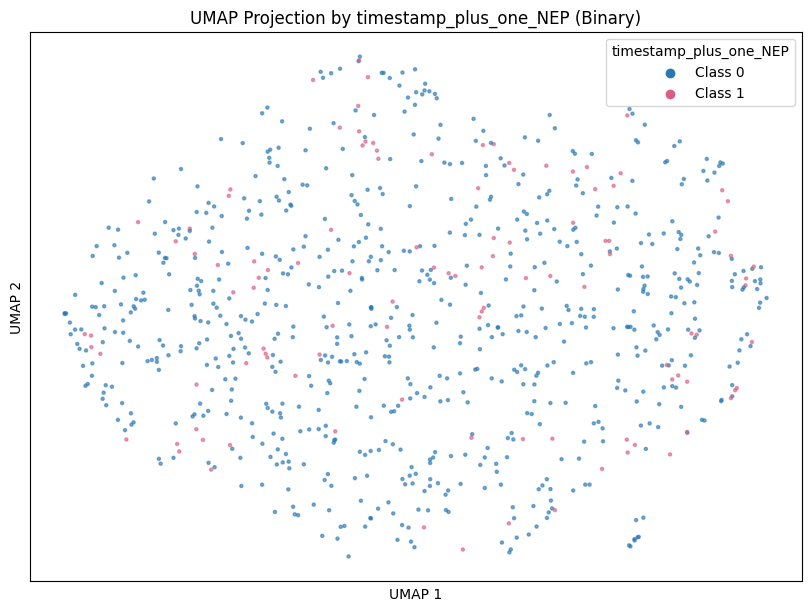

In [10]:
# gemini gave me this re-working of the umap chunk
# 1. Compute UMAP embeddings
umap_table = cohort.copy()
umap_table[['UMAP1', 'UMAP2']] = UMAP(
    n_neighbors=50, random_state=SEED, n_jobs=1
).fit_transform(umap_table[embedding_columns])

# 2. Filter out missing values and sample/shuffle points to avoid overplotting bias
plot_table = (
    umap_table.dropna(subset=['timestamp_plus_one_NEP'])
    .sample(frac=1, random_state=SEED)
)

# 3. Define explicit colors for class 0 and class 1
colors = {0: '#2878B5', 1: '#D95F82'}  # Blue for 0, Pink/Red for 1

# 4. Create the scatter plot
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Scatter plot using mapped colors
ax.scatter(
    plot_table['UMAP1'],
    plot_table['UMAP2'],
    c=plot_table['timestamp_plus_one_NEP'].map(colors),
    s=5,
    alpha=0.6,  # Helps visualize overlapping points
)

# Add legend entries manually
for label, color in colors.items():
    ax.scatter([], [], color=color, label=f'Class {label}')

# 5. Styling
ax.set_title('UMAP Projection by timestamp_plus_one_NEP (Binary)')
ax.set(xticks=[], yticks=[], xlabel='UMAP 1', ylabel='UMAP 2')
ax.legend(title='timestamp_plus_one_NEP')

plt.show()

## encode the evaluation targets
- tbh i am slightly losing the will to live - will pick this up tomorrow.
- maybe quickly before i go i can run a quick LR or something...

In [16]:
# need to do a proper train test split
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# 1. Extract the 5-character participant ID from the DataFrame index
group_id = df.index.astype(str).str[:5]

# 2. Set up the grouped splitter (e.g., 80% train / 20% test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# 3. Generate train/test indices using group_id
train_idx, test_idx = next(gss.split(df, groups=group_id))

# 4. Split the DataFrame using integer location (.iloc)
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Sanity Check: Verify zero overlap between train and test participants
train_participants = set(train_df.index.astype(str).str[:5])
test_participants = set(test_df.index.astype(str).str[:5])
overlap = train_participants.intersection(test_participants)

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")
print(
    f"Unique train participants: {len(train_participants)} | Unique test participants: {len(test_participants)}"
)
print(f"Participant overlap: {len(overlap)} (Should be 0)")

Train samples: 1819 | Test samples: 455
Unique train participants: 1819 | Unique test participants: 455
Participant overlap: 0 (Should be 0)


In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

# 1. Identify feature columns automatically (embedding_000 through embedding_XXX)
feature_cols = cohort.filter(regex=r"^embedding_").columns

# 2. Extract features and target, dropping rows with missing values
clean_df = cohort.dropna(subset=["timestamp_plus_one_NEP"] + list(feature_cols))
X = clean_df[feature_cols]
y = clean_df["timestamp_plus_one_NEP"]

# Extract 5-character participant group IDs directly from the index
groups = clean_df.index.astype(str).str[:5]

# 3. Split using StratifiedGroupKFold to maintain label balance AND group independence
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

# Slice features and target arrays using iloc
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Scale features (essential for high-dimensional embeddings)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train_scaled, y_train)

# 6. Evaluate
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.88       147
         1.0       0.24      0.29      0.26        21

    accuracy                           0.80       168
   macro avg       0.57      0.58      0.57       168
weighted avg       0.81      0.80      0.81       168

ROC-AUC Score: 0.6025


In [18]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Identify feature columns automatically (embedding_000 through embedding_XXX)
feature_cols = cohort.filter(regex=r"^embedding_").columns

# 2. Extract features and target, dropping rows with missing values
clean_df = cohort.dropna(subset=["timestamp_plus_one_NEP"] + list(feature_cols))
X = clean_df[feature_cols]
y = clean_df["timestamp_plus_one_NEP"]

# Extract 5-character participant group IDs directly from the index
groups = clean_df.index.astype(str).str[:5]

# 3. Split using StratifiedGroupKFold to maintain label balance AND group independence
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

# Slice features and target arrays using iloc
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Scale features (essential for high-dimensional embeddings and SVM distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Support Vector Classifier
# - probability=True is required to enable predict_proba for ROC-AUC
# - kernel='rbf' is default; try kernel='linear' if features are very high-dimensional
clf = SVC(kernel="rbf", probability=True, random_state=SEED)
clf.fit(X_train_scaled, y_train)

# 6. Evaluate
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.93       147
         1.0       0.00      0.00      0.00        21

    accuracy                           0.88       168
   macro avg       0.44      0.50      0.47       168
weighted avg       0.77      0.88      0.82       168

ROC-AUC Score: 0.4869


/home/lucy/miniconda3/envs/Sensori/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/lucy/miniconda3/envs/Sensori/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucy/miniconda3/envs/Sensori/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lucy/min